In [ ]:
import json, glob, numpy as np, pandas as pd
from IPython.display import display, Markdown

configs = {"RNN-GAN": "rnngan", "RNN-GAN + head": "rnngan_con",
           "TimeGAN": "timegan", "TimeGAN + head": "timegan_con"}
metrics = {"KL spread": ("KL spread vs real", "≤ 0.1"),
           "KL returns": ("KL returns vs real", "≤ 0.1"),
           "Invalid books (%)": ("Any invariant broken (%)", "≤ 1"),
           "Zero returns (%)": ("Zero returns (%)", "≈ 36.6"),
           "Windows trending up (%)": ("Windows trending up (%)"f, "≈ 50"),
           "Diversity": ("Diversity: std of window-mean spread", "≈ 1.61"),
           "Vol clustering ACF(1)": ("Vol clustering: ACF |ret| lag 1", "≈ 0.10")}

runs = {label: [json.load(open(f)) for f in sorted(glob.glob(f"results/{prefix}_s[0-2].json"))]
        for label, prefix in configs.items()}
print({label: len(r) for label, r in runs.items()}, "  expect 3 runs per configuration")

# Summary: mean ± std across seeds
summary = {name: {"Target": target} | {label: f"{np.mean(v):.3f} ± {np.std(v):.3f}"
                                       for label, r in runs.items()
                                       for v in [[x["best_val_metrics"][key] for x in r]]}
           for name, (key, target) in metrics.items()}
summary["Train time (s)"] = {"Target": ""} | {label: f"{np.mean([x['train_seconds'] for x in r]):.0f}" for label, r in runs.items()}
display(Markdown("### Trial 2: validation metrics at each run's best checkpoint (mean ± std, 3 seeds)"))
display(pd.DataFrame(summary).T.style.set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "center")]}]))

# Per seed: one column per configuration and seed
per_seed = {name: {(label, f"s{s}"): f"{x['best_val_metrics'][key]:.3f}"
                   for label, r in runs.items() for s, x in enumerate(r)}
            for name, (key, _) in metrics.items()}
per_seed["Best checkpoint step"] = {(label, f"s{s}"): str(x["best_step"]) for label, r in runs.items() for s, x in enumerate(r)}
df = pd.DataFrame(per_seed).T
df.columns = pd.MultiIndex.from_tuples(df.columns)
display(Markdown("### Per seed"))
display(df.style.set_properties(**{"text-align": "center"}))

# Markdown version, to paste straight into the README
print("| Metric | Target | " + " | ".join(configs) + " |\n|---|---|" + "---|" * len(configs))
for name, row in summary.items():
    print(f"| {name} | {row['Target']} | " + " | ".join(row[c] for c in configs) + " |")

{'RNN-GAN': 3, 'RNN-GAN + head': 3, 'TimeGAN': 3, 'TimeGAN + head': 3}   expect 3 runs per configuration


### Trial 2: validation metrics at each run's best checkpoint (mean ± std, 3 seeds)

,Target,RNN-GAN,RNN-GAN + head,TimeGAN,TimeGAN + head
KL spread,≤ 0.1,0.394 ± 0.214,0.510 ± 0.237,0.130 ± 0.011,0.157 ± 0.031
KL returns,≤ 0.1,0.863 ± 0.173,0.785 ± 0.489,0.517 ± 0.030,0.473 ± 0.081
Invalid books (%),≤ 1,32.309 ± 8.207,0.000 ± 0.000,45.744 ± 5.958,0.000 ± 0.000
Zero returns (%),≈ 36.6,7.480 ± 1.975,11.105 ± 6.447,6.341 ± 0.781,7.566 ± 2.002
Windows trending up (%),≈ 50,8.991 ± 11.715,37.972 ± 31.710,55.858 ± 15.099,46.772 ± 2.226
Diversity,≈ 1.61,0.668 ± 0.194,0.598 ± 0.139,1.322 ± 0.360,2.016 ± 0.245
Vol clustering ACF(1),≈ 0.10,-0.097 ± 0.233,0.476 ± 0.309,0.277 ± 0.048,0.450 ± 0.064
Train time (s),,159,217,237,275


### Per seed

| Metric | Target | RNN-GAN | RNN-GAN + head | TimeGAN | TimeGAN + head |
|---|---|---|---|---|---|
| KL spread | ≤ 0.1 | 0.394 ± 0.214 | 0.510 ± 0.237 | 0.130 ± 0.011 | 0.157 ± 0.031 |
| KL returns | ≤ 0.1 | 0.863 ± 0.173 | 0.785 ± 0.489 | 0.517 ± 0.030 | 0.473 ± 0.081 |
| Invalid books (%) | ≤ 1 | 32.309 ± 8.207 | 0.000 ± 0.000 | 45.744 ± 5.958 | 0.000 ± 0.000 |
| Zero returns (%) | ≈ 36.6 | 7.480 ± 1.975 | 11.105 ± 6.447 | 6.341 ± 0.781 | 7.566 ± 2.002 |
| Windows trending up (%) | ≈ 50 | 8.991 ± 11.715 | 37.972 ± 31.710 | 55.858 ± 15.099 | 46.772 ± 2.226 |
| Diversity | ≈ 1.61 | 0.668 ± 0.194 | 0.598 ± 0.139 | 1.322 ± 0.360 | 2.016 ± 0.245 |
| Vol clustering ACF(1) | ≈ 0.10 | -0.097 ± 0.233 | 0.476 ± 0.309 | 0.277 ± 0.048 | 0.450 ± 0.064 |
| Train time (s) |  | 159 | 217 | 237 | 275 |


## Price paths (30 random windows)

### RNN-GAN

**RNN-GAN, seed 0**

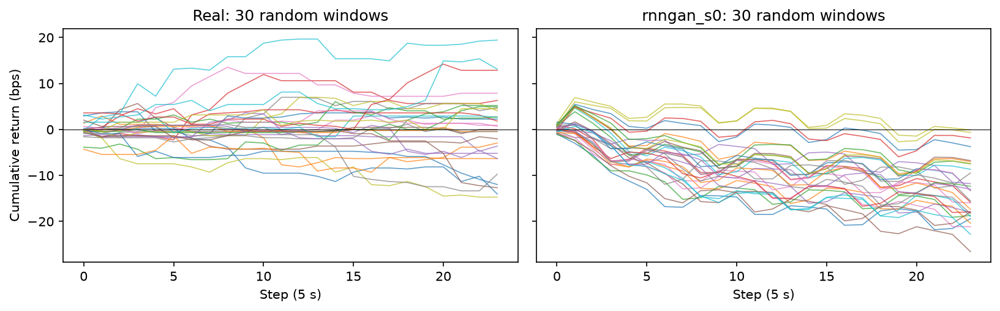

**RNN-GAN, seed 1**

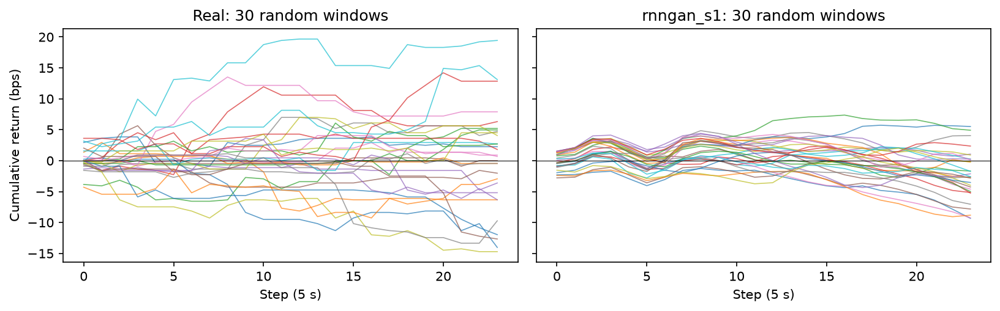

**RNN-GAN, seed 2**

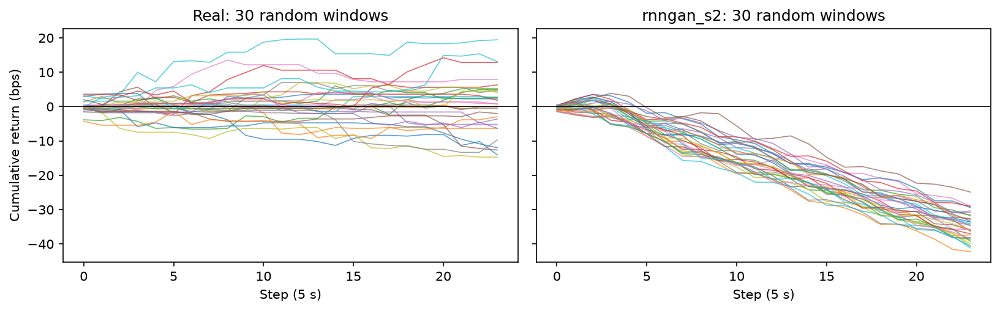

### RNN-GAN + head

**RNN-GAN + head, seed 0**

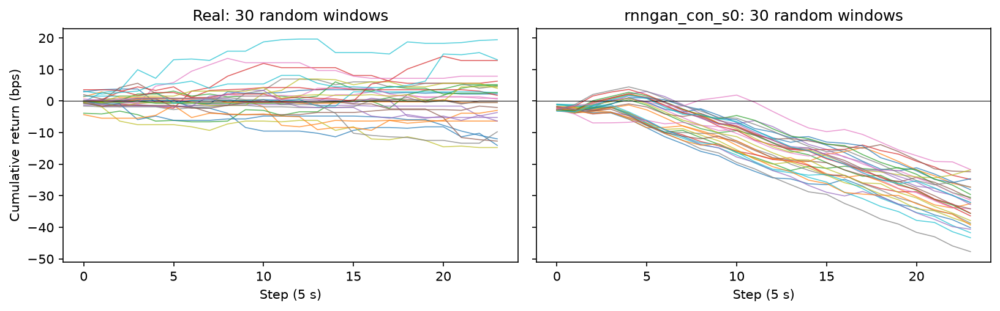

**RNN-GAN + head, seed 1**

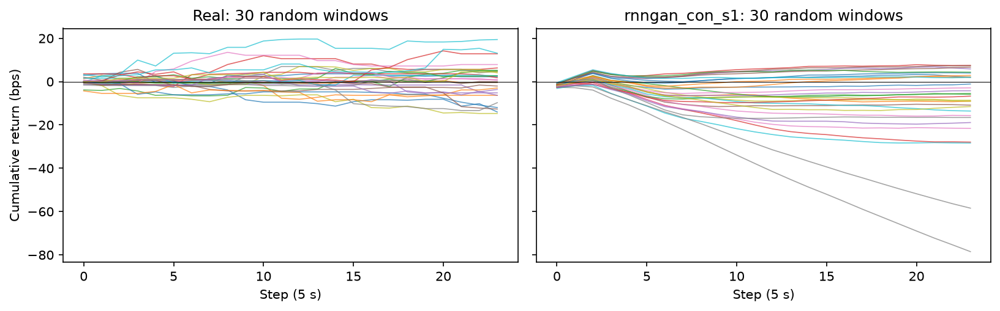

**RNN-GAN + head, seed 2**

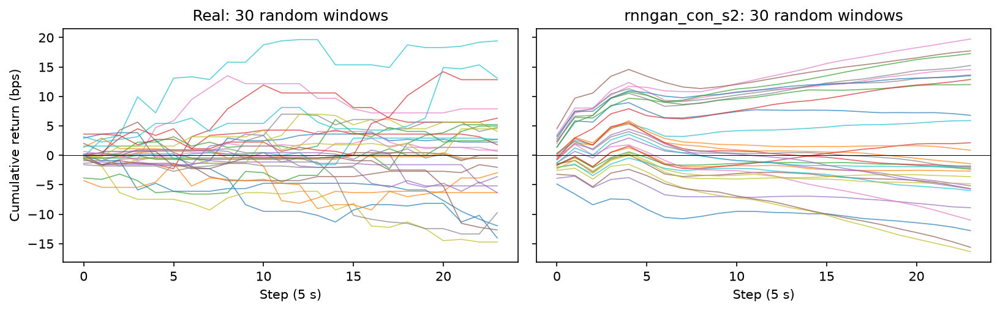

### TimeGAN

**TimeGAN, seed 0**

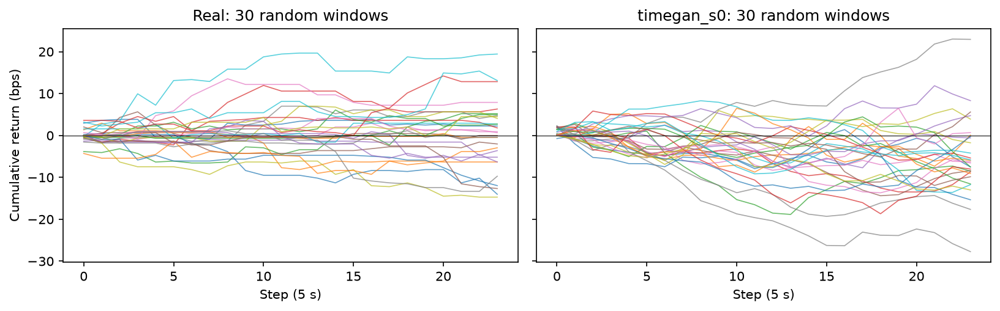

**TimeGAN, seed 1**

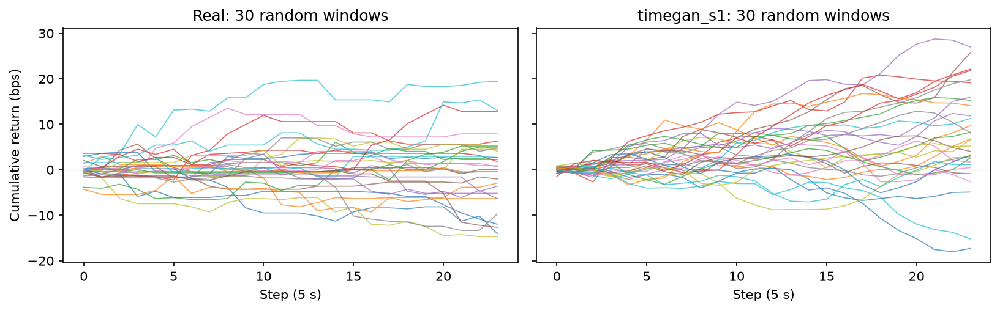

**TimeGAN, seed 2**

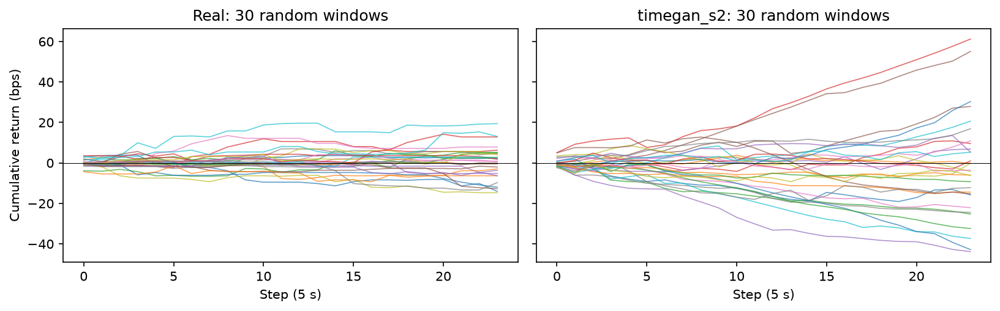

### TimeGAN + head

**TimeGAN + head, seed 0**

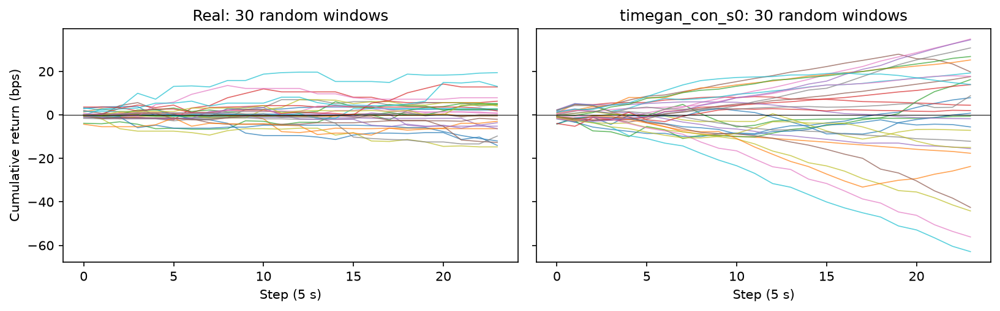

**TimeGAN + head, seed 1**

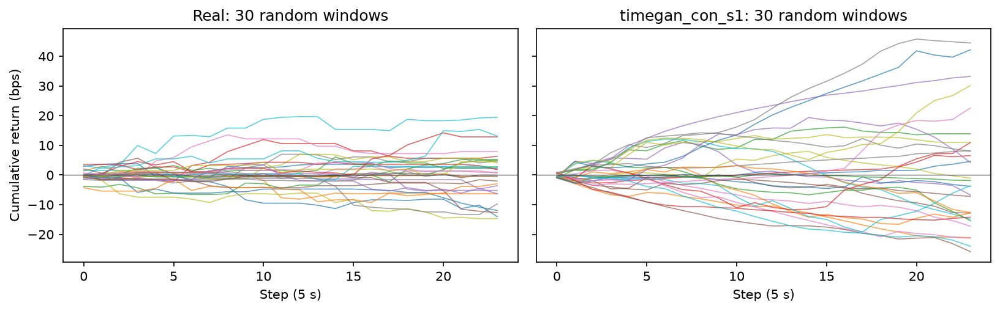

**TimeGAN + head, seed 2**

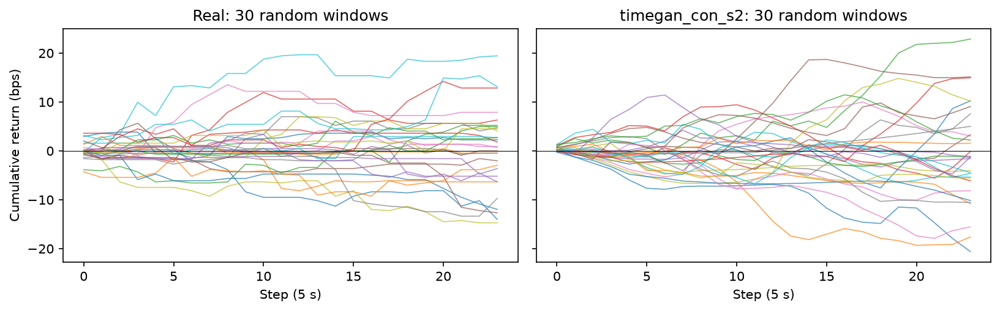

## Spread, return and clustering distributions

### RNN-GAN

**RNN-GAN, seed 0**

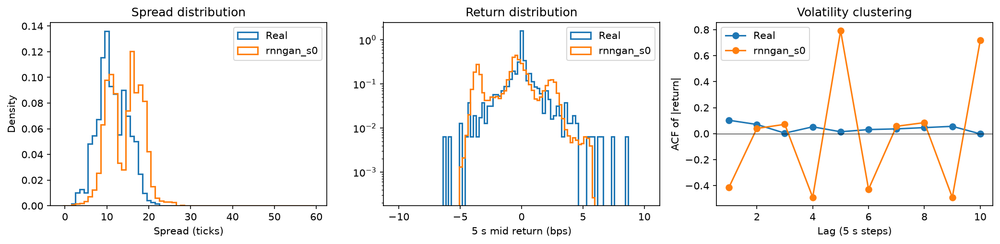

**RNN-GAN, seed 1**

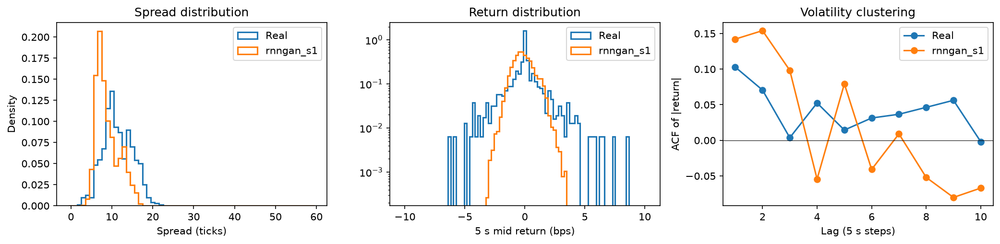

**RNN-GAN, seed 2**

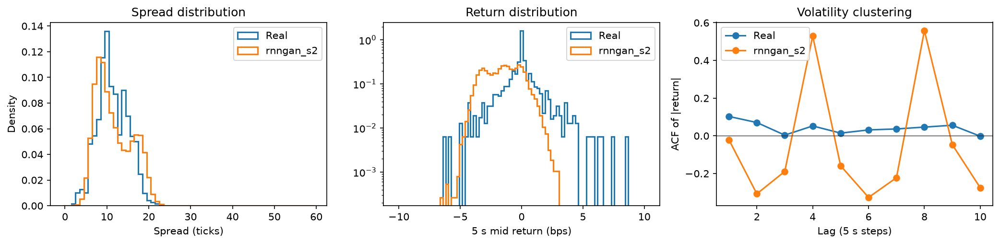

### RNN-GAN + head

**RNN-GAN + head, seed 0**

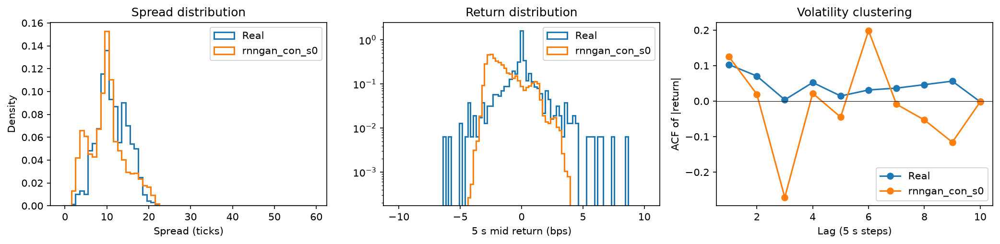

**RNN-GAN + head, seed 1**

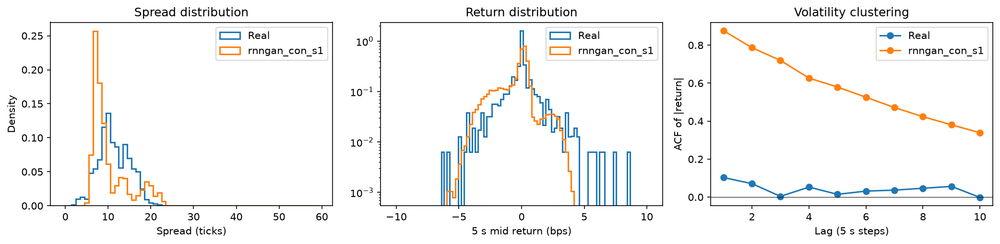

**RNN-GAN + head, seed 2**

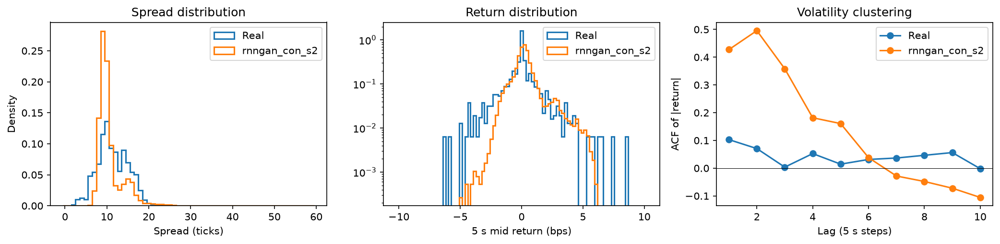

### TimeGAN

**TimeGAN, seed 0**

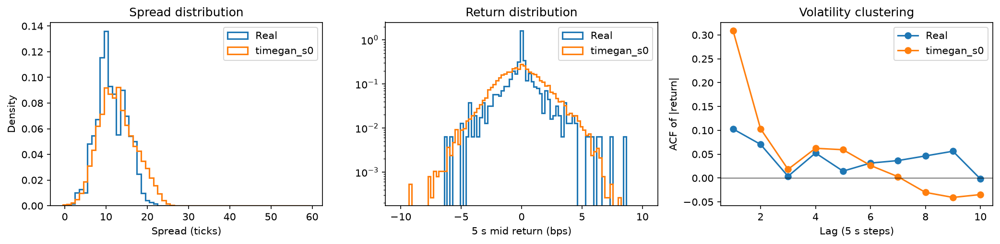

**TimeGAN, seed 1**

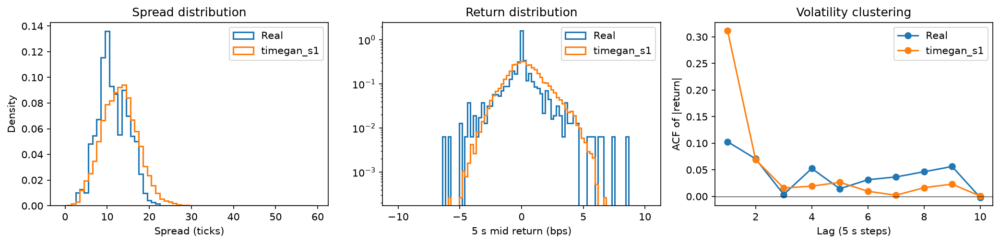

**TimeGAN, seed 2**

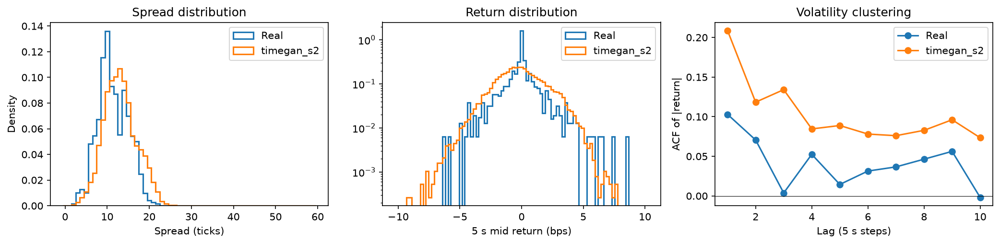

### TimeGAN + head

**TimeGAN + head, seed 0**

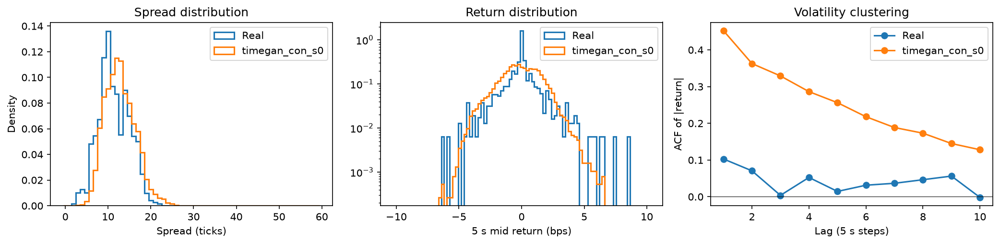

**TimeGAN + head, seed 1**

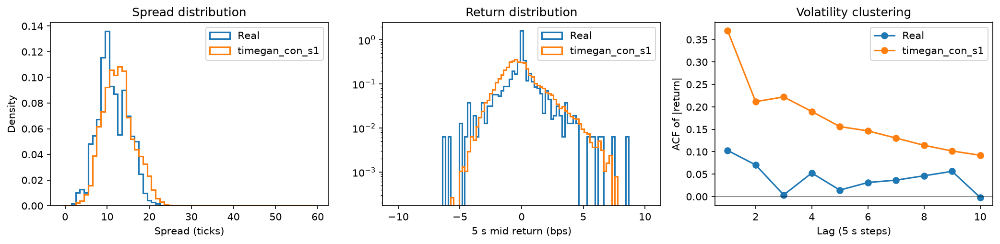

**TimeGAN + head, seed 2**

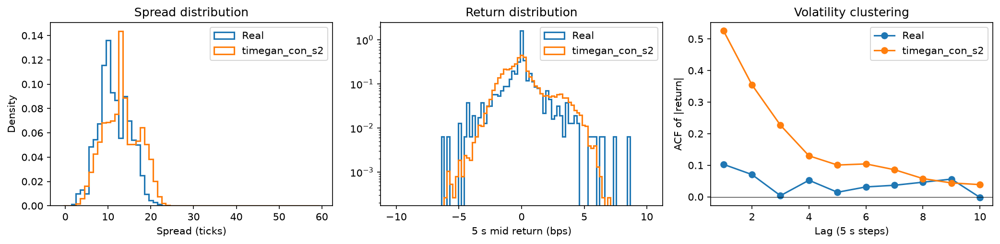

## Price ladder and depth heatmap

### RNN-GAN

**RNN-GAN, seed 0**

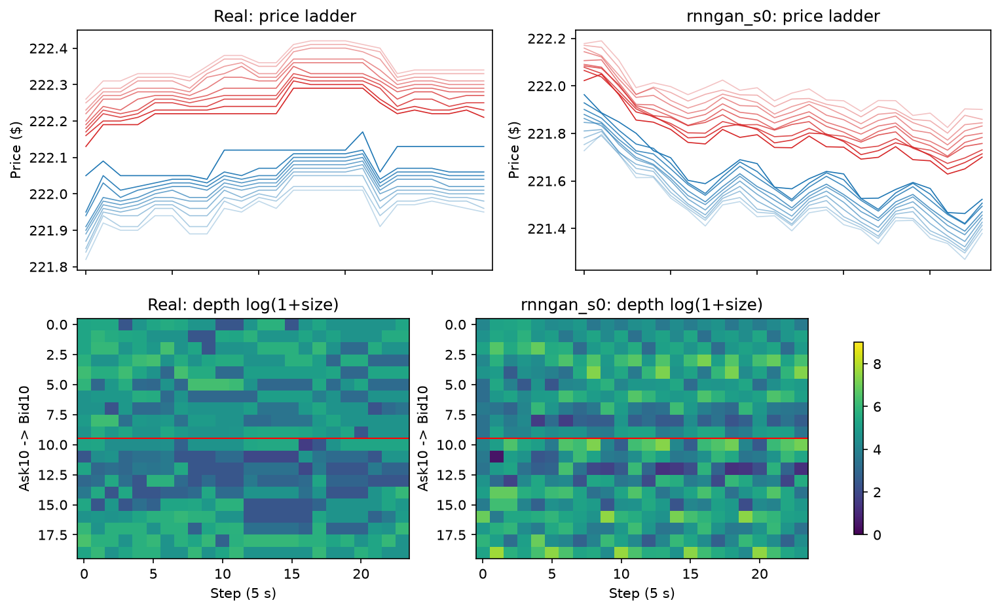

**RNN-GAN, seed 1**

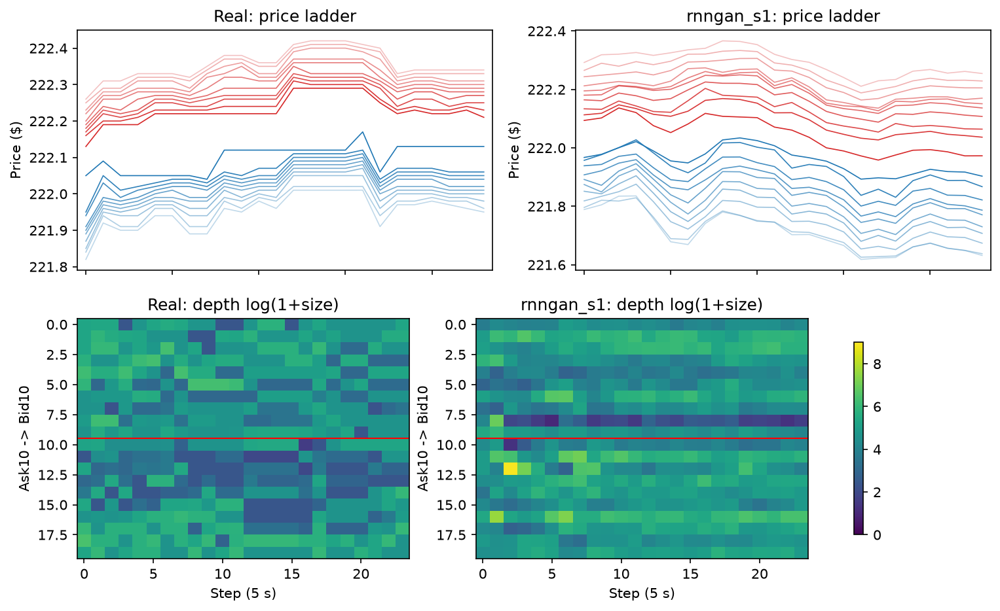

**RNN-GAN, seed 2**

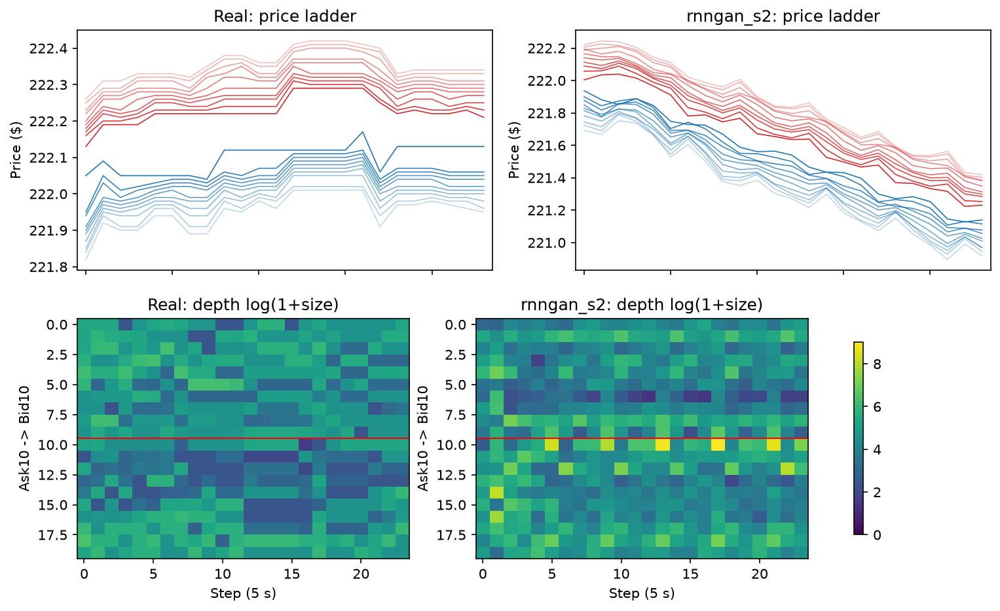

### RNN-GAN + head

**RNN-GAN + head, seed 0**

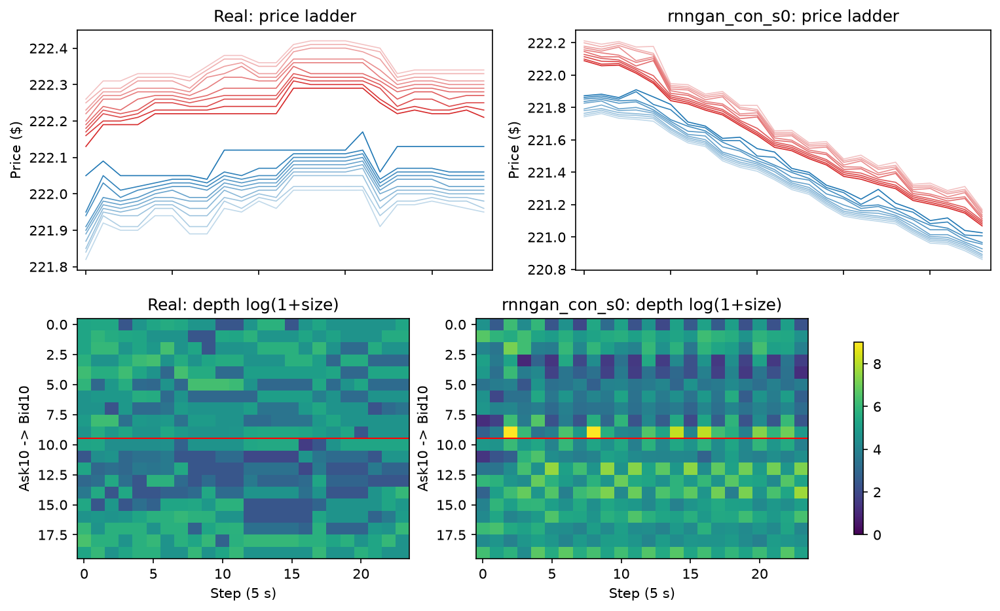

**RNN-GAN + head, seed 1**

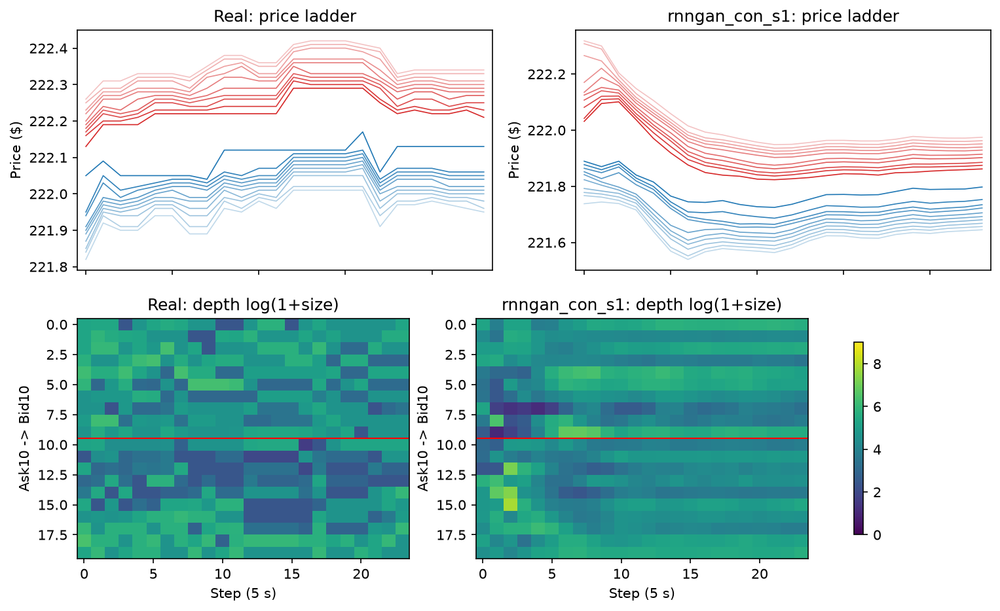

**RNN-GAN + head, seed 2**

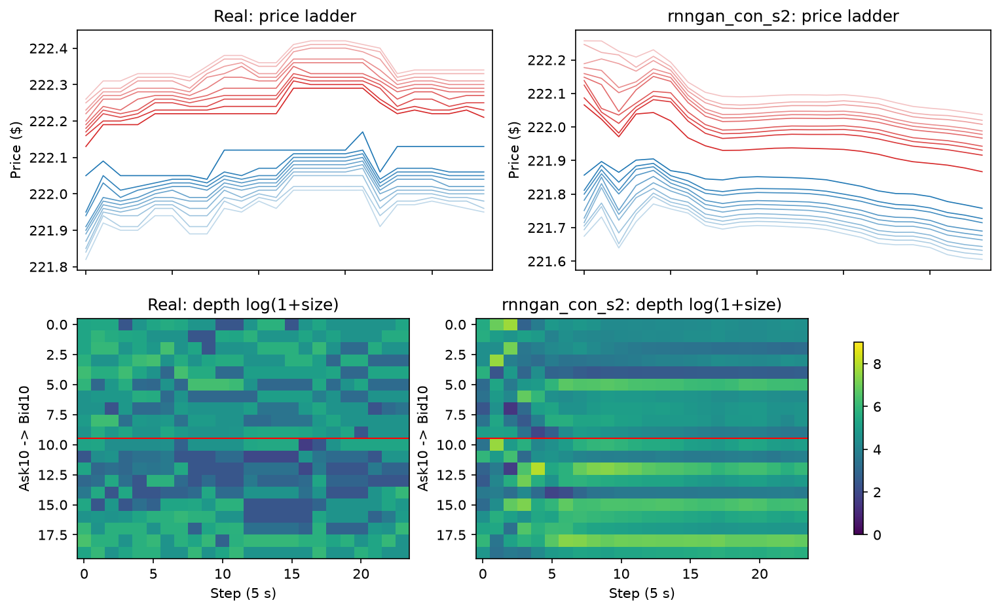

### TimeGAN

**TimeGAN, seed 0**

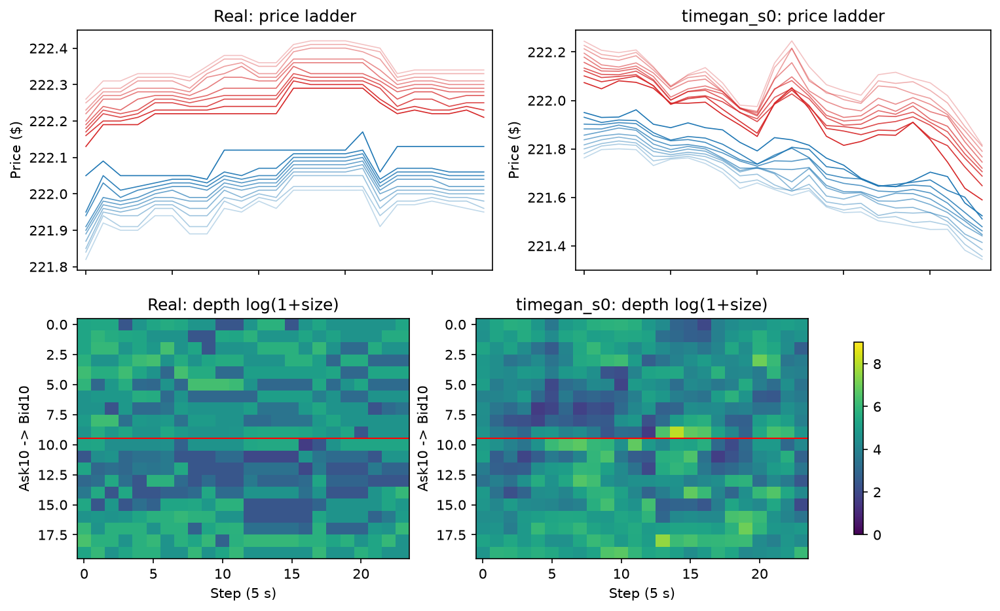

**TimeGAN, seed 1**

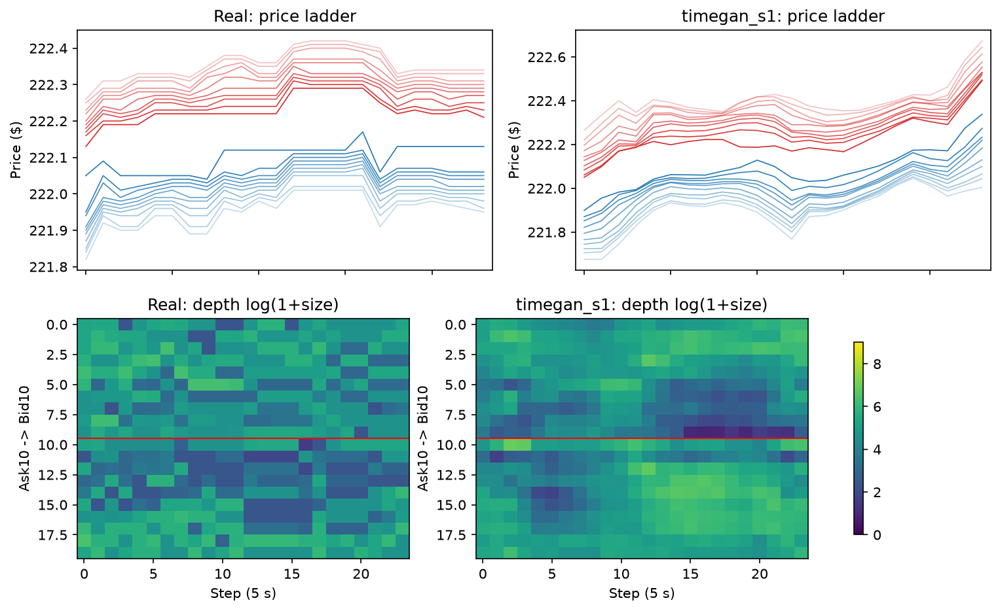

**TimeGAN, seed 2**

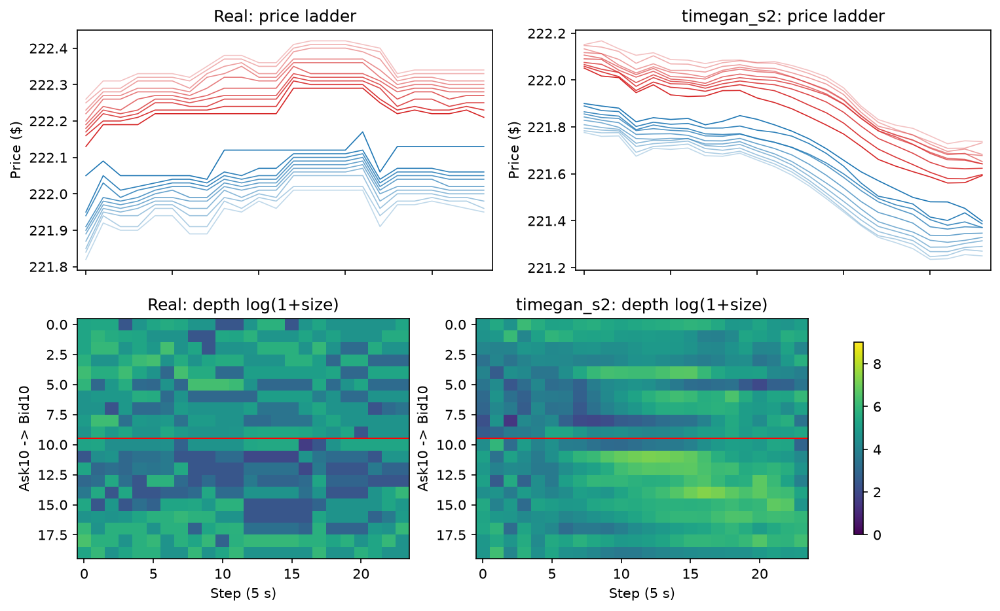

### TimeGAN + head

**TimeGAN + head, seed 0**

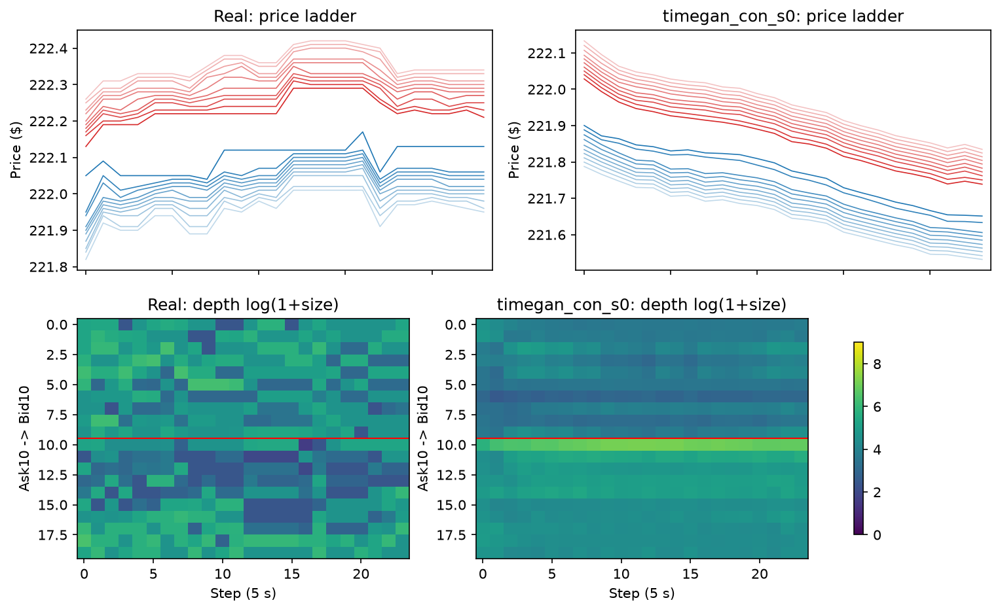

**TimeGAN + head, seed 1**

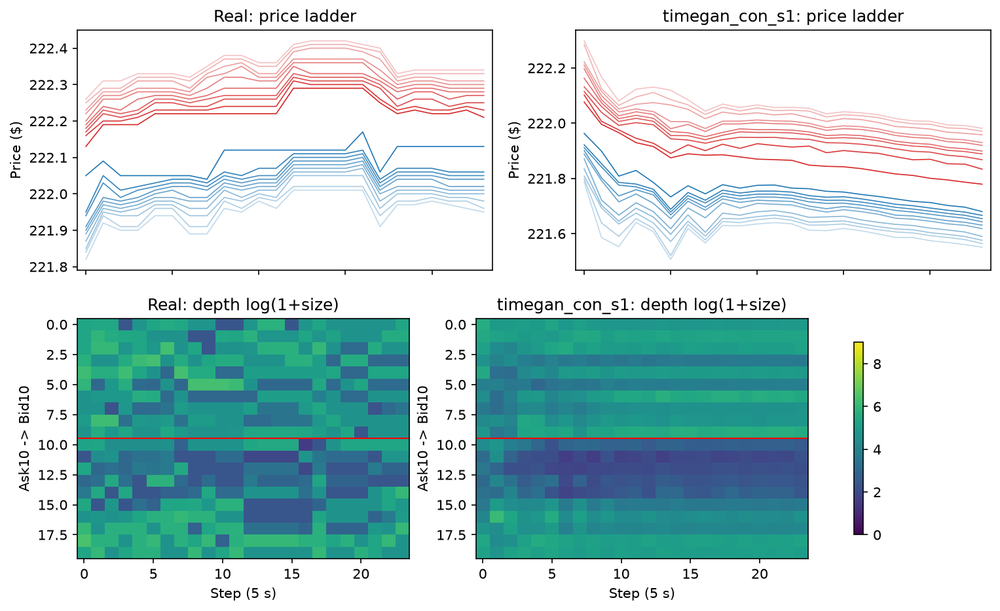

**TimeGAN + head, seed 2**

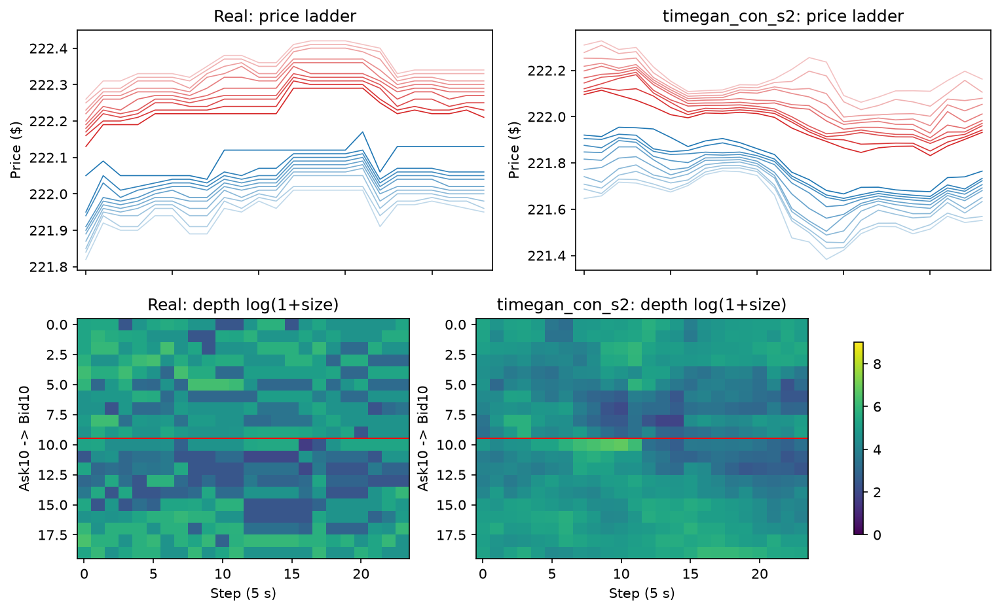

## Training losses

### RNN-GAN

**RNN-GAN, seed 0**

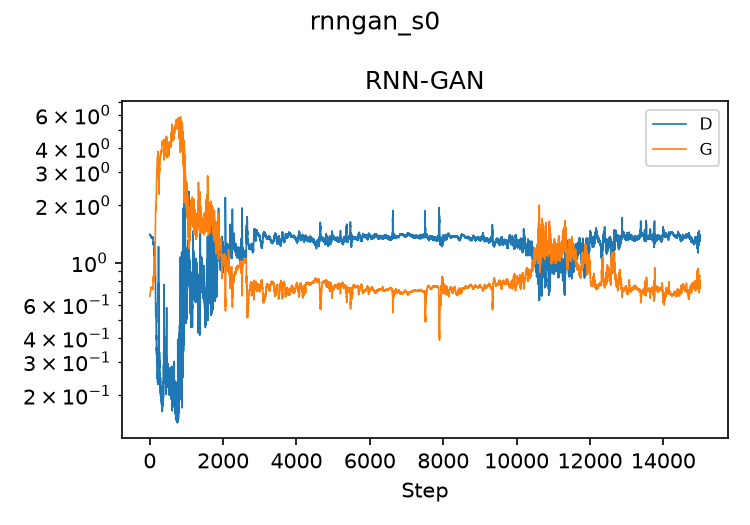

**RNN-GAN, seed 1**

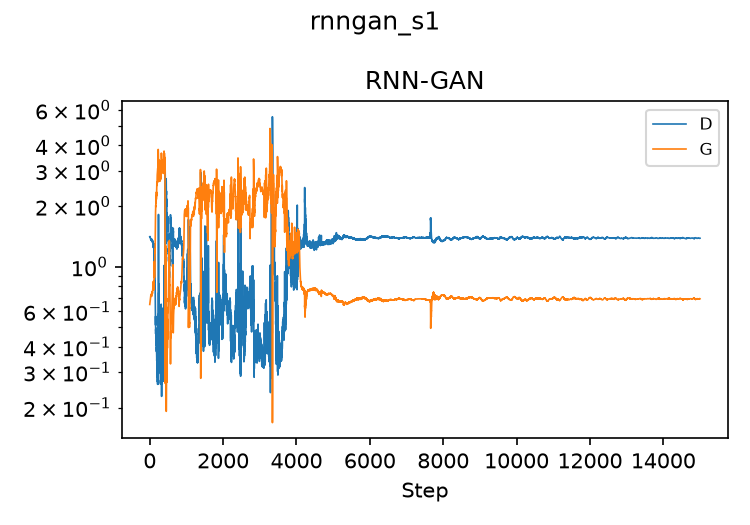

**RNN-GAN, seed 2**

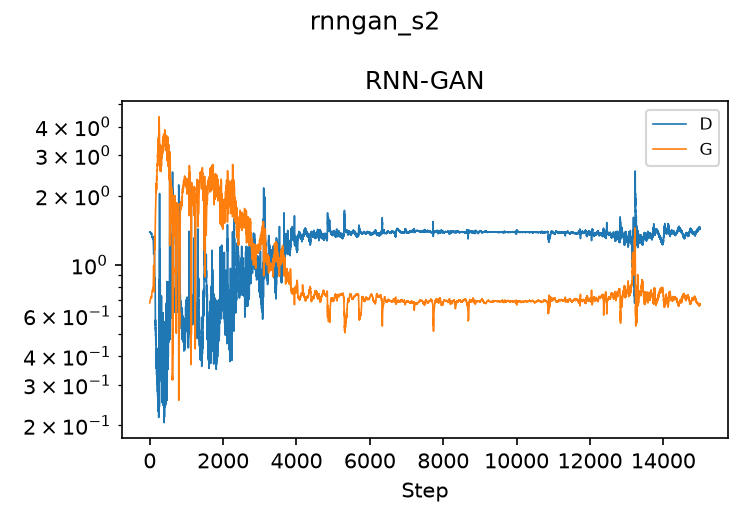

### RNN-GAN + head

**RNN-GAN + head, seed 0**

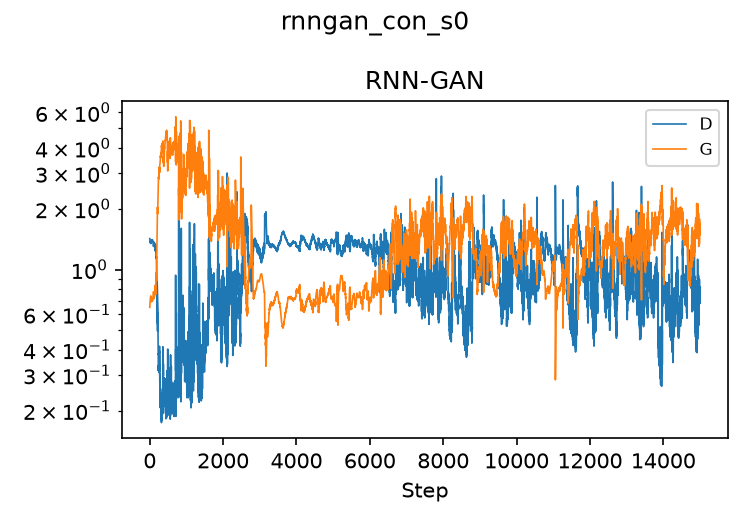

**RNN-GAN + head, seed 1**

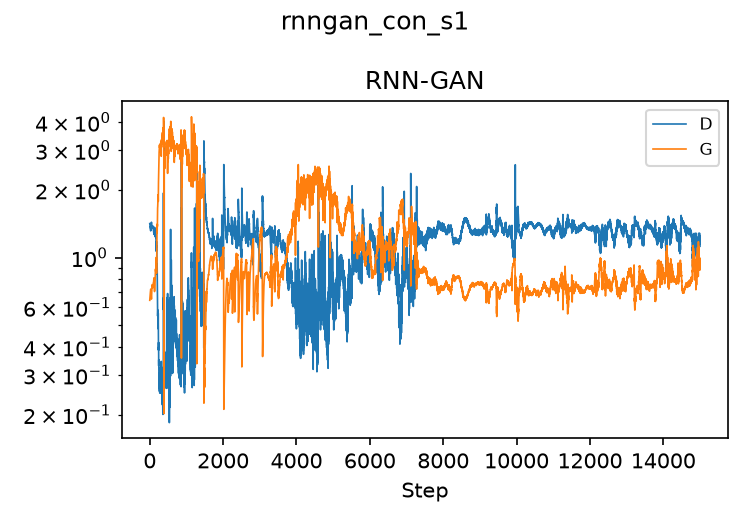

**RNN-GAN + head, seed 2**

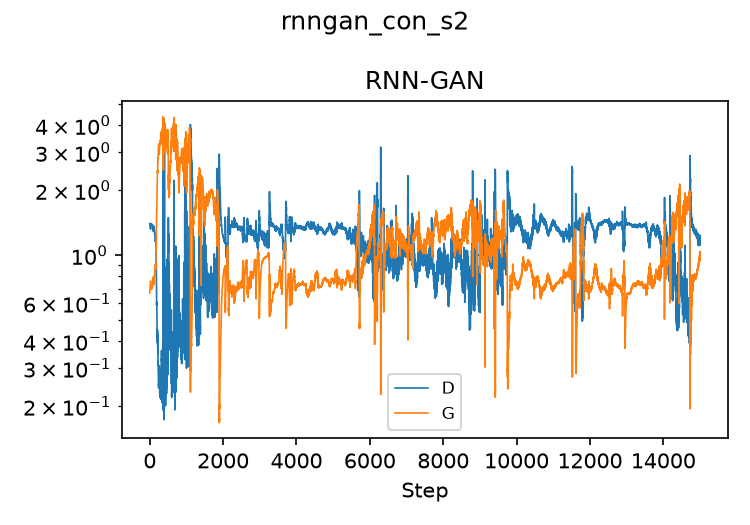

### TimeGAN

**TimeGAN, seed 0**

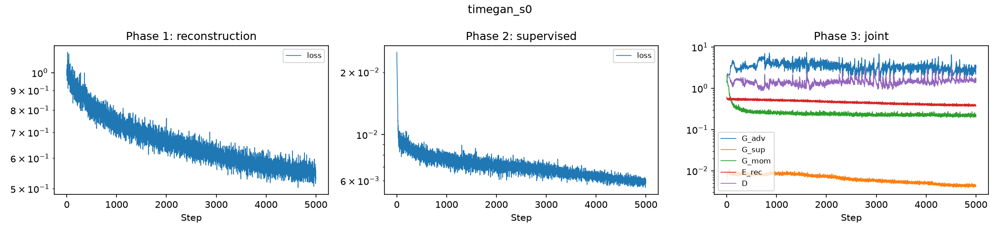

**TimeGAN, seed 1**

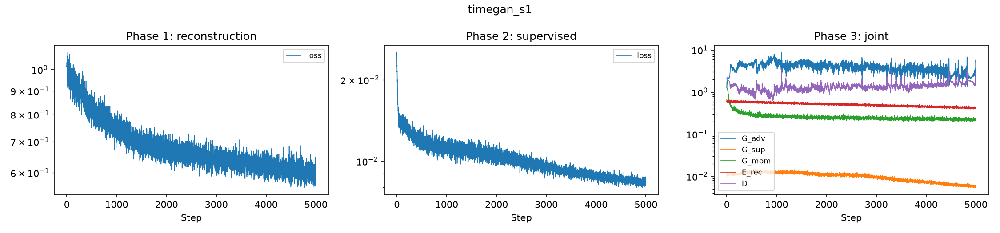

**TimeGAN, seed 2**

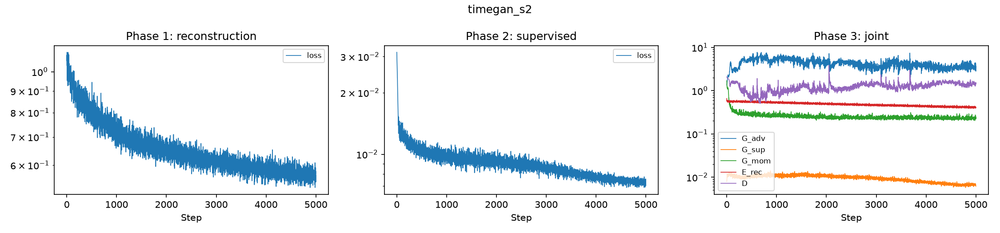

### TimeGAN + head

**TimeGAN + head, seed 0**

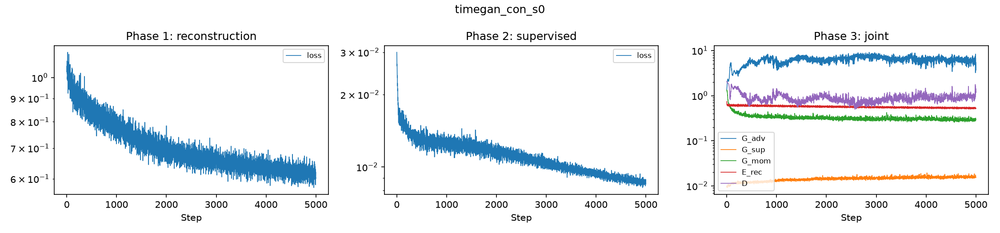

**TimeGAN + head, seed 1**

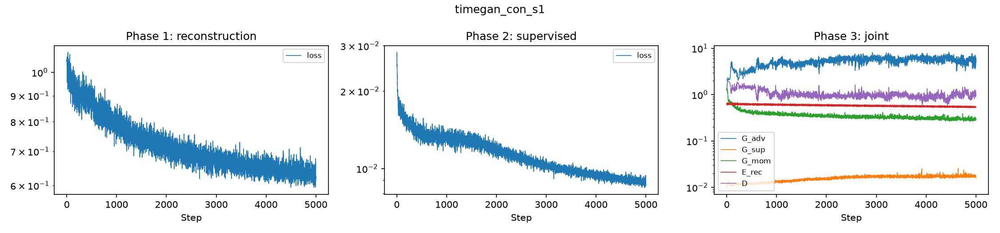

**TimeGAN + head, seed 2**

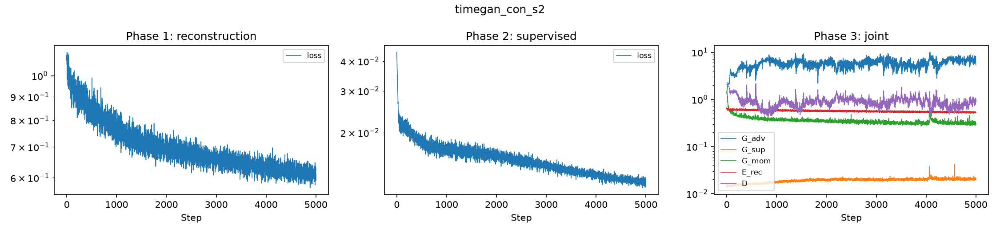

In [2]:
from IPython.display import Image, Markdown, display

kinds = {"val_paths": "Price paths (30 random windows)", "val_dists": "Spread, return and clustering distributions",
         "val_book": "Price ladder and depth heatmap", "losses": "Training losses"}
show_kinds = list(kinds)          # e.g. ["val_book"] to show just one type
show_configs = list(configs)      # e.g. ["TimeGAN", "TimeGAN + head"] to compare just two

for kind in show_kinds:
    display(Markdown(f"## {kinds[kind]}"))
    for label in show_configs:
        display(Markdown(f"### {label}"))
        for seed in range(3):
            display(Markdown(f"**{label}, seed {seed}**"))
            display(Image(f"figures/{configs[label]}_s{seed}_{kind}.png", width=850))

In [3]:
import sys; sys.path.insert(0, "..")                      # project .py files are one folder up
import torch, torch.nn as nn, numpy as np, pandas as pd, utils
from dataset import get_data
from modules import (RNNGenerator, rnngan_generate, TGGenerator, TGSupervisor, TGRecovery,
                     tg_generate, ConstrainedHead)

train_loader, val_w, test_w, stats = get_data("~/Desktop/LOBSTER")
cols = list(stats["mean"].index)
pos = [cols.index("spread")] + [i for i, c in enumerate(cols) if "gap" in c]
vol = [i for i, c in enumerate(cols) if "logv" in c]
make_head = lambda: ConstrainedHead(torch.tensor(stats["mean"].to_numpy()), torch.tensor(stats["std"].to_numpy()), pos, vol)

def load_generator(prefix, seed):
    """Rebuild a saved model (constrained or not) and return a function that generates n windows."""
    ckpt = torch.load(f"checkpoints/{prefix}_s{seed}.pt", weights_only=False, map_location="cpu")
    wrap = (lambda n: nn.Sequential(n, make_head())) if ckpt["args"].get("constrained") else (lambda n: n)
    if ckpt["model"] == "timegan":
        G, S, R = TGGenerator(), TGSupervisor(), wrap(TGRecovery())
        for k, n in [("G", G), ("S", S), ("R", R)]:
            n.load_state_dict(ckpt[k]); n.eval()
        return lambda n: tg_generate(G, S, R, n)
    G = wrap(RNNGenerator()); G.load_state_dict(ckpt["G"]); G.eval()
    return lambda n: rnngan_generate(G, n)

keys = {"KL spread": "KL spread vs real", "KL returns": "KL returns vs real",
        "Zero returns (%)": "Zero returns (%)", "Invalid books (%)": "Any invariant broken (%)"}
configs = {"RNN-GAN + head": "rnngan_con", "TimeGAN": "timegan", "TimeGAN + head": "timegan_con"}
rows = {}
for label, prefix in configs.items():
    raw, snap = {k: [] for k in keys}, {k: [] for k in keys}
    for seed in range(3):
        torch.manual_seed(1234)
        fake = load_generator(prefix, seed)(len(val_w))
        for store, w in [(raw, fake), (snap, utils.snap_windows(fake, stats))]:
            m = utils.evaluate(val_w, w, stats, ssim=False)["fake"]
            for k, key in keys.items():
                store[k].append(m[key])
    for tag, store in [("raw", raw), ("snapped", snap)]:
        rows[f"{label} ({tag})"] = {k: f"{np.mean(v):.3f} ± {np.std(v):.3f}" for k, v in store.items()}

m = utils.evaluate(val_w, utils.snap_windows(val_w, stats), stats, ssim=False)["fake"]   # sanity check
rows["Real val, snapped (sanity)"] = {k: f"{m[key]:.3f}" for k, key in keys.items()}
display(pd.DataFrame(rows).T.style.set_caption("Validation metrics before and after tick-snapping (mean ± std, 3 seeds)"))

,KL spread,KL returns,Zero returns (%),Invalid books (%)
RNN-GAN + head (raw),0.489 ± 0.223,0.792 ± 0.480,10.669 ± 6.215,0.000 ± 0.000
RNN-GAN + head (snapped),0.489 ± 0.223,0.739 ± 0.482,12.245 ± 7.275,0.000 ± 0.000
TimeGAN (raw),0.123 ± 0.005,0.513 ± 0.030,6.392 ± 0.772,45.138 ± 6.359
TimeGAN (snapped),0.123 ± 0.005,0.524 ± 0.030,6.191 ± 0.991,71.903 ± 3.375
TimeGAN + head (raw),0.147 ± 0.028,0.485 ± 0.093,7.592 ± 2.256,0.000 ± 0.000
TimeGAN + head (snapped),0.147 ± 0.028,0.474 ± 0.088,8.011 ± 2.491,0.000 ± 0.000
"Real val, snapped (sanity)",0.000,0.004,35.874,0.000


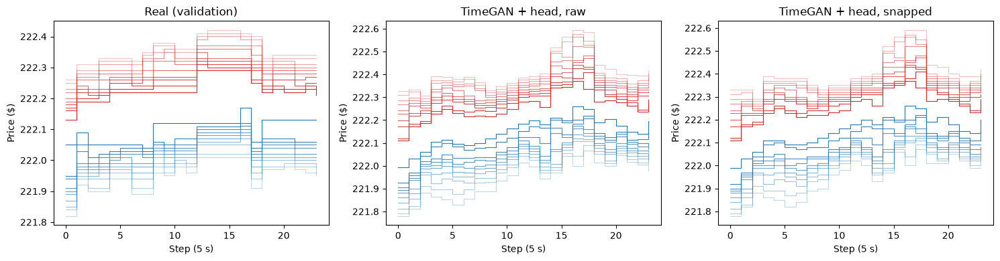

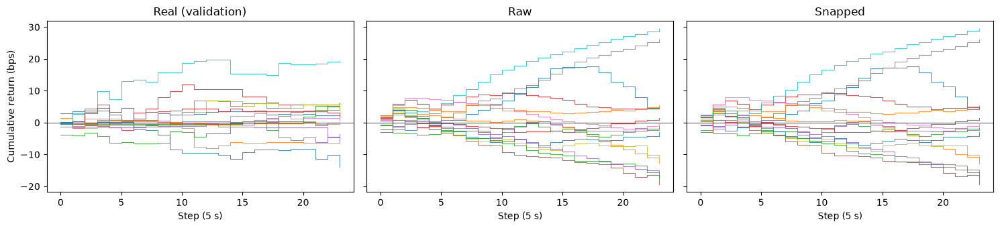

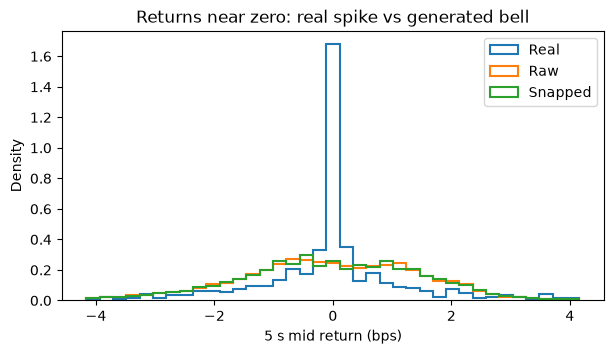

In [5]:
import matplotlib.pyplot as plt
ix = utils.feature_index(stats)
torch.manual_seed(1234)
raw = load_generator("timegan_con", 0)(len(val_w))
snap = utils.snap_windows(raw, stats)

# 1. Price ladder: one window, raw vs snapped vs a real window
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (name, w) in zip(axes, [("Real (validation)", val_w[0]), ("TimeGAN + head, raw", raw[0]), ("TimeGAN + head, snapped", snap[0])]):
    asks, bids, _, _ = utils.to_book(utils.unnormalise(w, stats), ix)
    for lvl in range(asks.shape[-1]):
        ax.step(range(24), asks[:, lvl] / 1e4, where="post", color="tab:red", lw=0.8, alpha=1 - lvl * 0.08)
        ax.step(range(24), bids[:, lvl] / 1e4, where="post", color="tab:blue", lw=0.8, alpha=1 - lvl * 0.08)
    ax.set(title=name, xlabel="Step (5 s)", ylabel="Price ($)")
fig.tight_layout(); plt.show()

# 2. Mid-price paths: 15 random windows, raw vs snapped
pick = torch.randperm(len(raw), generator=torch.Generator().manual_seed(0))[:15]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
for ax, (name, w) in zip(axes, [("Real (validation)", val_w), ("Raw", raw), ("Snapped", snap)]):
    paths = torch.cumsum(utils.unnormalise(w[pick], stats)[..., ix["ret"]], 1) * 1e4
    ax.step(range(24), paths.T.numpy(), where="post", lw=0.8, alpha=0.8)
    ax.axhline(0, color="black", lw=0.5); ax.set(title=name, xlabel="Step (5 s)")
axes[0].set_ylabel("Cumulative return (bps)")
fig.tight_layout(); plt.show()

# 3. Return distribution near zero: where the difference shows
fig, ax = plt.subplots(figsize=(7, 3.5))
edges = utils._ret_edges(0.225, span_bps=4)
for name, w, c in [("Real", val_w, "C0"), ("Raw", raw, "C1"), ("Snapped", snap, "C2")]:
    r = utils.unnormalise(w, stats)[..., ix["ret"]].numpy().ravel() * 1e4
    ax.hist(r, bins=edges, density=True, histtype="step", lw=1.5, color=c, label=name)
ax.set(xlabel="5 s mid return (bps)", ylabel="Density", title="Returns near zero: real spike vs generated bell")
ax.legend(); plt.show()